# Inverse Code Challenges and Solutions to Practice Questions

In [11]:
import numpy as np

A = np.array([[1, 3, 0], [0, -2, 8], [7, 2, -6]])

print("Original Matrix:\n", A)

print("Det =", np.linalg.det(A))

print("Inverse of A: (scaled by det)\n", np.linalg.inv(A) * np.linalg.det(A))

print("Product of A and its inverse:\n", np.round(A @ (np.linalg.inv(A))))

Original Matrix:
 [[ 1  3  0]
 [ 0 -2  8]
 [ 7  2 -6]]
Det = 163.99999999999991
Inverse of A: (scaled by det)
 [[-4. 18. 24.]
 [56. -6. -8.]
 [14. 19. -2.]]
Product of A and its inverse:
 [[ 1.  0.  0.]
 [-0.  1.  0.]
 [ 0.  0.  1.]]


## Code Challenge 1: MCA algorithm in code

- Implement the MCA algorithm for calculating the matrix inverse
- Compare with numpy's matrix inverse

In [57]:
# Matrix size
m = 3

# Generate matrix
A = np.random.randint(0, 10, (m, m))
print("A:\n", A)

# First identify if matrix is invertable
if np.linalg.det(A) == 0:
    print("Matrix is non-invertable")
else:
    # Preallocate
    A_minor = np.zeros(np.shape(A))

    # Remove row that current element is in
    for i in range(np.size(A, 0)):
        subset_A0 = np.delete(A, i, 0)
        # Remove column that current element is in
        for j in range(np.size(A, 1)):
            subset_A1 = np.delete(subset_A0, j, 1)
            # Calculate the det of each of the subsets of A
            A_minor[i, j] = np.linalg.det(subset_A1)
    print("Minor matrix of A:\n", A_minor)

    # Flatted A_minor into 1D array to allow for multiplying every second element by -1
    cofactor_Aminor = np.ndarray.flatten(np.copy(A_minor))
    # Multiply every second element by -1
    for l in range(1, np.size(A_minor), 2):
        cofactor_Aminor[l] = cofactor_Aminor[l] * -1
    # Unflatten the new array back into original shape
    cofactor_Aminor = np.reshape(cofactor_Aminor, np.shape(A_minor))
    print("Cofactor * Minor Matrix A:\n", cofactor_Aminor)

    # Calculate the inverse by scaling by 1/determinant
    A_inv = cofactor_Aminor * (1 / np.linalg.det(A))

    # Inverse I calculated
    print("Calculated inverse:\n", A_inv)
    # Inverse using np
    print("Np Inverse: \n", np.linalg.inv(A))

    print("Difference matrix: \n", np.round(A_inv - np.linalg.inv(A)))

A:
 [[6 1 4]
 [4 9 6]
 [2 7 7]]
Minor matrix of A:
 [[ 21.  16.  10.]
 [-21.  34.  40.]
 [-30.  20.  50.]]
Cofactor * Minor Matrix A:
 [[ 21. -16.  10.]
 [ 21.  34. -40.]
 [-30. -20.  50.]]
Calculated inverse:
 [[ 0.14       -0.10666667  0.06666667]
 [ 0.14        0.22666667 -0.26666667]
 [-0.2        -0.13333333  0.33333333]]
Np Inverse: 
 [[ 0.14        0.14       -0.2       ]
 [-0.10666667  0.22666667 -0.13333333]
 [ 0.06666667 -0.26666667  0.33333333]]
Difference matrix: 
 [[ 0. -0.  0.]
 [ 0.  0. -0.]
 [-0.  0.  0.]]


In [40]:
print(range(0, np.size(A_minor), 2))

range(0, 9, 2)


## Code Challenge 2: Diagonal matrices and their inverse

- Create some diagonal matrices (Start with 2x2 of ints, then work up to bigger)
- Compute their inverses (condition on diagonal matrices for invertability)
- "Think"

In [81]:
import numpy as np
from sympy import *


# Set n
n = 5

# Generate a diagonal matrix of size n x n
A = Matrix(np.diag(np.diag(np.random.randint(1, 10, (n, n)))))
print("Diagonal Matrix A:")
pprint(A)
print()

A_inv = A.inv()
print("Inverse of A:")
pprint(A_inv)

Diagonal Matrix A:
⎡7  0  0  0  0⎤
⎢             ⎥
⎢0  3  0  0  0⎥
⎢             ⎥
⎢0  0  9  0  0⎥
⎢             ⎥
⎢0  0  0  4  0⎥
⎢             ⎥
⎣0  0  0  0  3⎦

Inverse of A:
⎡1/7   0    0    0    0 ⎤
⎢                       ⎥
⎢ 0   1/3   0    0    0 ⎥
⎢                       ⎥
⎢ 0    0   1/9   0    0 ⎥
⎢                       ⎥
⎢ 0    0    0   1/4   0 ⎥
⎢                       ⎥
⎣ 0    0    0    0   1/3⎦


## Code Challenge 3: Is the pseudoinverse identical to the regular inverse for full-rank, square matrices?
- Generate an invertible matrix
- Compare the pseudoinverse and the inverse

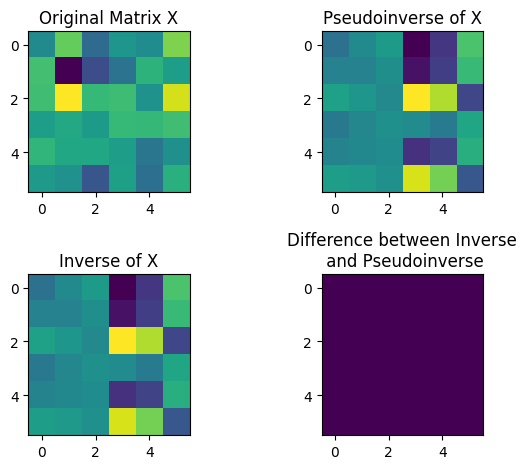

In [127]:
import matplotlib.pyplot as plt

# Define matrix size
n = 6

# Create invertible matrix
X = np.random.randn(n, n)
# print(X)

pinvX = np.linalg.pinv(X)
invX = np.linalg.inv(X)

fig, axes = plt.subplots(2, 2)

axes[0, 0].imshow(X)
axes[0, 0].set_title("Original Matrix X")

axes[0, 1].imshow(pinvX)
axes[0, 1].set_title("Pseudoinverse of X")

axes[1, 0].imshow(invX)
axes[1, 0].set_title("Inverse of X")

axes[1, 1].imshow(np.round(invX - pinvX))
axes[1, 1].set_title("Difference between Inverse\n and Pseudoinverse")

plt.tight_layout()
plt.show()